## Setup

In [1]:
# Set seed for reproducibility
SEED = 42

# Import necessary libraries
import os

# Set environment variables before importing modules
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['MPLCONFIGDIR'] = os.getcwd() + '/configs/'

# Suppress warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)

# Import necessary modules
import logging
import random
import numpy as np

# Set seeds for random number generators in NumPy and Python
np.random.seed(SEED)
random.seed(SEED)

# Import PyTorch
import torch
torch.manual_seed(SEED)
from torch import nn
import torchvision
import torchvision.transforms as transforms
from torchvision import models
from torchsummary import summary
from torch.utils.data import TensorDataset, Dataset, DataLoader
!pip install torchview
from torchview import draw_graph
!pip install rangerlite
from rangerlite import RangerLite
!pip install pytorch-optimizer
from pytorch_optimizer import Ranger
import timm

if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

# Import other libraries
import cv2
import copy
import shutil
from itertools import product
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
from PIL import Image, ImageOps
import matplotlib.gridspec as gridspec
import requests
import re
from io import BytesIO
import torch.optim as optim
from collections import defaultdict
import gc
from torchvision.models import ResNet18_Weights

# Configure plot display settings
sns.set(font_scale=1.4)
sns.set_style('white')
plt.rc('font', size=14)
%matplotlib inline

PyTorch version: 2.6.0+cu124
Device: cuda


In [77]:
from torchvision.models import EfficientNet_B4_Weights

## Data Loading

In [78]:
def sample_centers_from_mask(mask, n, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    ys, xs = np.where(mask > 0)
    if len(xs) == 0:
        return []
    idx = rng.integers(0, len(xs), size=n)
    return list(zip(xs[idx], ys[idx]))

def crop_patch(arr, cx, cy, patch):
    H, W = arr.shape[:2]
    x0 = int(np.clip(cx - patch//2, 0, W - patch))
    y0 = int(np.clip(cy - patch//2, 0, H - patch))
    return arr[y0:y0+patch, x0:x0+patch]

def extract_patches_maskaware(img, mask, patch=380, n_patches=6,
                             fallback="random", min_mask_frac=0.01,
                             max_tries=50, rng=None):

    if rng is None:
        rng = np.random.default_rng()

    H, W = mask.shape

    if H == patch and W == patch:
        return [(img, mask)]
    
    patches = []
    tries = 0

    while len(patches) < n_patches and tries < max_tries:
        tries += 1

        centers = sample_centers_from_mask(mask, 1, rng=rng)

        if centers:
            cx, cy = centers[0]
        else:
            # fallback if mask is empty
            if fallback == "center":
                cx, cy = W//2, H//2
            else:
                cx = int(rng.integers(0, W))
                cy = int(rng.integers(0, H))

        ip = crop_patch(img,  cx, cy, patch)
        mp = crop_patch(mask, cx, cy, patch)

        # skip patch if it has insufficient mask coverage
        if mask.sum() > 0 and mp.mean() < min_mask_frac:
            continue

        patches.append((ip, mp))

    # fallback if no valid patches were found
    if not patches:
        cx = int(rng.integers(0, W))
        cy = int(rng.integers(0, H))
        patches.append((crop_patch(img, cx, cy, patch), crop_patch(mask, cx, cy, patch)))

    return patches

In [79]:
def get_bbox(mask):
    ys, xs = np.where(mask > 0)
    if xs.size == 0:
        return None
    return xs.min(), ys.min(), xs.max() + 1, ys.max() + 1

def extract_crop_from_mask(arr, mask, min_size=380):
    bbox = get_bbox(mask)
    if bbox is None:
        return arr
    x0, y0, x1, y1 = bbox
    # skip crop if bounding box is too small
    if (x1 - x0) < min_size or (y1 - y0) < min_size:
        return arr
    return arr[y0:y1, x0:x1]

def pad_to_min_size(arr, min_size=380):
    H, W = arr.shape[:2]
    if H >= min_size and W >= min_size:
        return arr

    dh = max(0, min_size - H)
    dw = max(0, min_size - W)

    top = dh // 2
    bottom = dh - top
    left = dw // 2
    right = dw - left

    return cv2.copyMakeBorder(
        arr, top, bottom, left, right,
        borderType=cv2.BORDER_CONSTANT,
        value=0
    )

def load_images_from_folder(folder):
    imgs, masks, file_names = [], [], []
    filenames = sorted([f for f in os.listdir(folder)
                        if f.startswith("img") and f.endswith(".png")])

    for filename in filenames:
        img = cv2.imread(os.path.join(folder, filename))
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # artifact filter (HSV-based booger removal)
        hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
        lower = np.array([35, 80, 160], dtype=np.uint8)
        upper = np.array([60, 255, 255], dtype=np.uint8)
        M_art = cv2.inRange(hsv, lower, upper)
        if np.mean(M_art > 0) >= 0.01:
            continue

        mask_name = filename.replace("img", "mask")
        mask = cv2.imread(os.path.join(folder, mask_name), cv2.IMREAD_GRAYSCALE)
        if mask is None:
            continue
        mask = (mask > 0).astype(np.uint8)

        # crop to mask bounding box
        img_crop  = extract_crop_from_mask(img,  mask, min_size=380)
        mask_crop = extract_crop_from_mask(mask, mask, min_size=380)

        img_crop  = pad_to_min_size(img_crop,  min_size=380)
        mask_crop = pad_to_min_size(mask_crop, min_size=380)

        mask_crop = (mask_crop > 0).astype(np.uint8)

        imgs.append(img_crop)
        masks.append(mask_crop)
        file_names.append(filename)

    return imgs, masks, file_names

In [80]:
data, masks, file_names = load_images_from_folder("/kaggle/input/an2dl2526c2v2/train_data")
print(f"Loaded {len(data)} data")

Loaded 581 data


## Data Visualization

In [81]:
def plot_10_images(data, titles=None):
    assert len(data) >= 10, "Need at least 10 images"

    fig, axes = plt.subplots(2, 5, figsize=(18, 7))
    axes = axes.flatten()

    for i in range(10):
        axes[i].imshow(data[i])
        axes[i].axis("off")
        if titles is not None:
            axes[i].set_title(titles[i], fontsize=10)

    plt.tight_layout()
    plt.show()

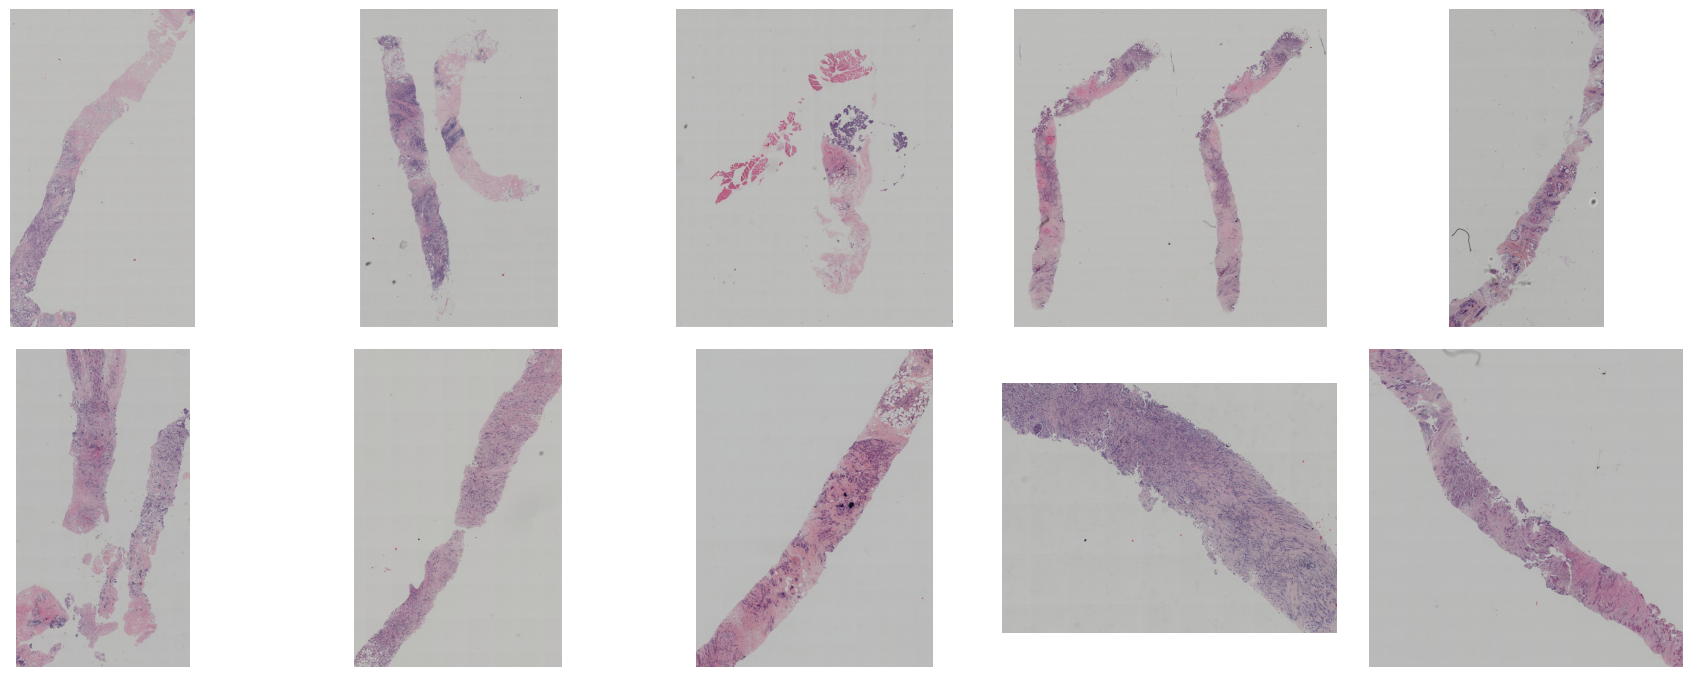

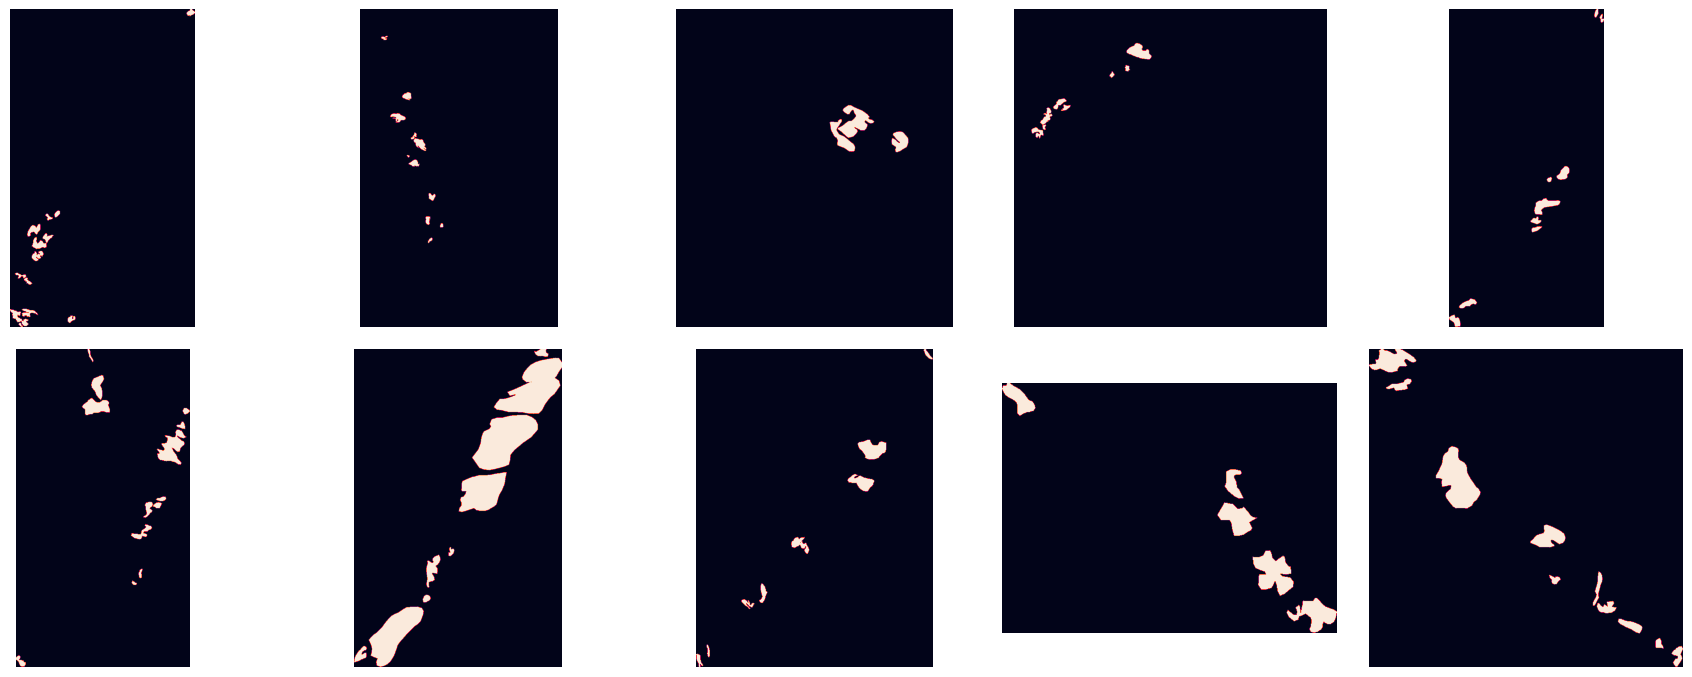

In [82]:
plot_10_images(data)
plot_10_images(masks)

In [83]:
patches = extract_patches_maskaware(data[10], masks[10], patch=380, n_patches=8)

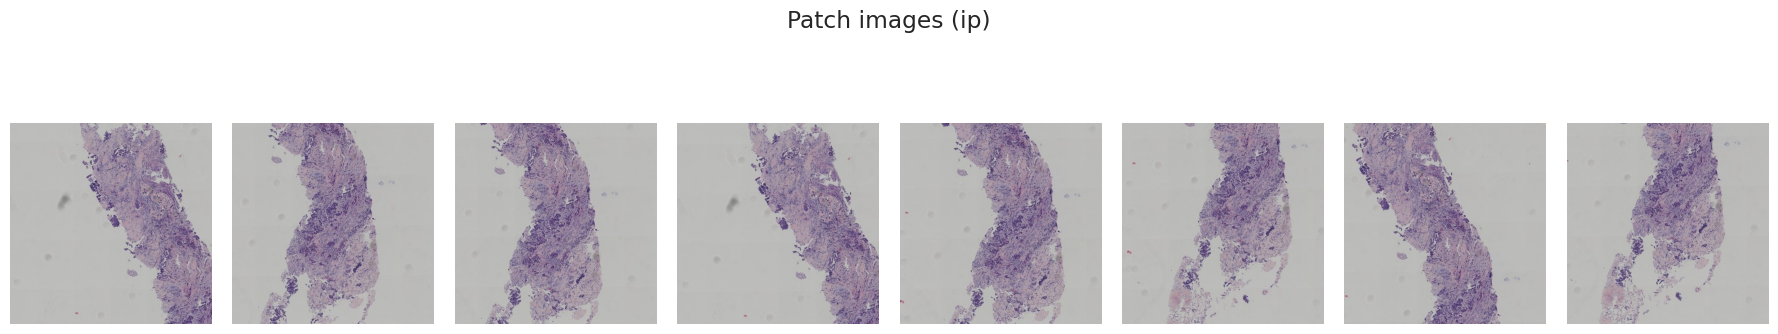

In [84]:
indices = list(range(8))

plt.figure(figsize=(18, 4))
for i, idx in enumerate(indices):
    ip, mp = patches[idx]
    plt.subplot(1, 8, i + 1)
    plt.imshow(ip)
    plt.axis("off")

plt.suptitle("Patch images (ip)")
plt.tight_layout()
plt.show()

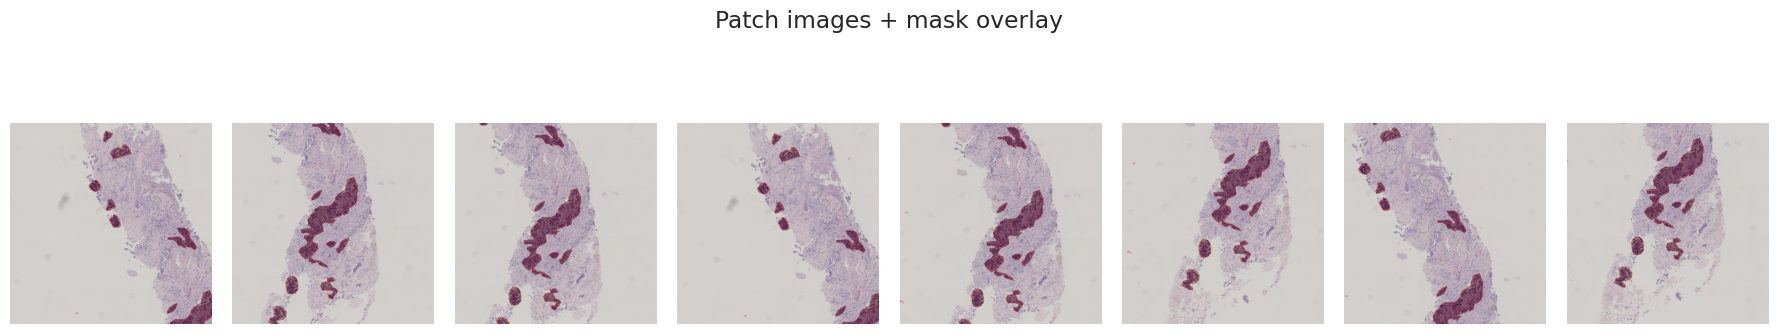

In [85]:
indices = list(range(8))

plt.figure(figsize=(18, 4))
for i, idx in enumerate(indices):
    ip, mp = patches[idx]
    plt.subplot(1, len(indices), i+1)
    plt.imshow(ip)
    plt.imshow(mp, cmap="Reds", alpha=0.35)
    plt.axis("off")

plt.suptitle("Patch images + mask overlay")
plt.tight_layout()
plt.show()

## Data Manipulation

In [86]:
labels = pd.read_csv("/kaggle/input/an2dl2526c2v2/train_labels.csv")

labels_map = {
    "Triple negative": 0,
    "Luminal A": 1,
    "Luminal B": 2,
    "HER2(+)": 3
}

# keep only labels for loaded images
labels = labels[labels["sample_index"].isin(file_names)].copy()

# reorder labels to match image loading order
labels = labels.set_index("sample_index").loc[file_names].reset_index()

y_train_val = labels["label"].map(labels_map).to_numpy()

In [87]:
idx = np.arange(len(data))

idx_train, idx_val = train_test_split(
    idx, random_state=SEED, test_size=0.1, stratify=y_train_val
)

X_train = [data[i] for i in idx_train]
M_train = [masks[i] for i in idx_train]
y_train = y_train_val[idx_train]

X_val = [data[i] for i in idx_val]
M_val = [masks[i] for i in idx_val]
y_val = y_train_val[idx_val]

In [88]:
# Define the number of classes
num_classes = len(np.unique(y_train))

print("Number of Classes:", num_classes)

Number of Classes: 4


In [89]:
unique, counts = np.unique(y_train, return_counts=True)
print(dict(zip(unique, counts)))

{0: 62, 1: 142, 2: 183, 3: 135}


In [90]:
class_counts = torch.tensor(counts, dtype=torch.float32, device=device)
weights = 1.0 / class_counts
weights = weights / weights.sum()  # normalize

In [91]:
mean = [0.0, 0.0, 0.0]
std  = [1.0, 1.0, 1.0]

train_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=4),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

val_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

In [92]:
class MILDataset(Dataset):
    def __init__(self, images, masks, labels=None, patch=380, n_patches=8,
                 transform_img=None, mode="train", seed=42):
        self.images = images
        self.masks = masks
        self.labels = labels
        self.patch = patch
        self.n_patches = n_patches
        self.transform_img = transform_img
        self.mode = mode
        self.seed = seed

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img  = self.images[idx]
        mask = self.masks[idx]

        # deterministic RNG for validation, random for training
        rng = np.random.default_rng(None if self.mode == "train" else (self.seed + idx))

        patches = extract_patches_maskaware(
            img, mask,
            patch=self.patch,
            n_patches=self.n_patches,
            rng=rng,                 
            min_mask_frac=0.01,      
            max_tries=50             
        )

        if len(patches) == 0:
            patches = [(img, mask)]  # extreme fallback

        if len(patches) < self.n_patches:
            idxs = rng.choice(len(patches), size=self.n_patches, replace=True)
            patches = [patches[i] for i in idxs]

        xb = []
        for ip, mp in patches:
            if self.transform_img:
                ip = self.transform_img(ip)  # -> Tensor [3,H,W]
            else:
                ip = torch.from_numpy(ip).permute(2,0,1).float() / 255.0
            xb.append(ip)

        xb = torch.stack(xb, dim=0)  # [K,3,H,W]

        if self.labels is None:
            return xb
        y = int(self.labels[idx])
        return xb, y

In [93]:
batch_size = 4

In [94]:
train_dataset = MILDataset(X_train, M_train, y_train, patch=380, n_patches=4,
                           transform_img=train_transforms, mode="train", seed=SEED)
val_dataset   = MILDataset(X_val,   M_val,   y_val,   patch=380, n_patches=4,
                           transform_img=val_transforms, mode="val", seed=SEED)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

In [95]:
del X_train, M_train, X_val, M_val, y_train, y_val, data, masks, file_names
gc.collect()

75852

## Model Creation

In [96]:
model = models.efficientnet_b4(weights=EfficientNet_B4_Weights.IMAGENET1K_V1) 
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, num_classes)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

## Training

In [97]:
for p in model.parameters():
    p.requires_grad = False
for p in model.classifier.parameters():
    p.requires_grad = True

In [98]:
criterion = nn.CrossEntropyLoss(weight=weights)
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(
    params,
    lr=1e-3,
    weight_decay=1e-4
)
scaler = torch.cuda.amp.GradScaler() if device.type == "cuda" else None

In [24]:
if not os.path.exists("models"):
    os.makedirs("models")

In [99]:
def mil_pool(logits_bkc: torch.Tensor, method="mean"):
    """
    logits_bkc: [B, K, C]
    returns:    [B, C]
    """
    if method == "mean":
        return logits_bkc.mean(dim=1)
    if method == "max":
        return logits_bkc.max(dim=1).values
    raise ValueError(f"Unknown pooling method: {method}")

In [100]:
def train_one_epoch_mil(model, loader, criterion, optimizer, scaler, device,
                        pool_method="mean", f1_average="weighted"):
    model.train()
    running_loss = 0.0
    preds, targs = [], []

    for xb, y in loader:
        xb = xb.to(device, non_blocking=True)
        y  = y.to(device, non_blocking=True)

        B, K, Cc, H, W = xb.shape
        x = xb.view(B*K, Cc, H, W)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type=device.type, enabled=(device.type == "cuda")):
            logits = model(x)                          # [B*K, C]
            logits = logits.view(B, K, -1)             # [B,K,C]
            logits_img = mil_pool(logits, method=pool_method)  # [B,C]
            loss = criterion(logits_img, y)

        if scaler is not None and device.type == "cuda":
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        running_loss += loss.item() * B

        preds.append(logits_img.argmax(dim=1).detach().cpu().numpy())
        targs.append(y.detach().cpu().numpy())

    y_true = np.concatenate(targs)
    y_pred = np.concatenate(preds)

    epoch_loss = running_loss / len(loader.dataset)
    epoch_f1 = f1_score(y_true, y_pred, average=f1_average, zero_division=0)

    return epoch_loss, epoch_f1

@torch.no_grad()
def validate_one_epoch_mil(model, loader, criterion, device,
                           pool_method="mean", f1_average="weighted"):
    model.eval()
    running_loss = 0.0
    preds, targs = [], []

    for xb, y in loader:
        xb = xb.to(device, non_blocking=True)
        y  = y.to(device, non_blocking=True)

        B, K, Cc, H, W = xb.shape
        x = xb.view(B*K, Cc, H, W)

        with torch.amp.autocast(device_type=device.type, enabled=(device.type == "cuda")):
            logits = model(x)
            logits = logits.view(B, K, -1)
            logits_img = mil_pool(logits, method=pool_method)
            loss = criterion(logits_img, y)

        running_loss += loss.item() * B

        preds.append(logits_img.argmax(dim=1).cpu().numpy())
        targs.append(y.cpu().numpy())

    y_true = np.concatenate(targs)
    y_pred = np.concatenate(preds)

    epoch_loss = running_loss / len(loader.dataset)
    epoch_f1 = f1_score(y_true, y_pred, average=f1_average, zero_division=0)

    return epoch_loss, epoch_f1

def fit_mil(model, train_loader, val_loader, epochs, criterion, optimizer, scaler, device,
            patience=10, mode="max", pool_method="mean", f1_average="weighted",
            experiment_name="mil", save_dir="models"):

    os.makedirs(save_dir, exist_ok=True)
    best_path = os.path.join(save_dir, f"{experiment_name}_model.pt")

    hist = {"train_loss": [], "val_loss": [], "train_f1": [], "val_f1": []}

    best_metric = -1e9 if mode == "max" else 1e9
    patience_counter = 0
    best_epoch = 0

    for epoch in range(1, epochs + 1):
        tr_loss, tr_f1 = train_one_epoch_mil(
            model, train_loader, criterion, optimizer, scaler, device,
            pool_method=pool_method, f1_average=f1_average
        )
        va_loss, va_f1 = validate_one_epoch_mil(
            model, val_loader, criterion, device,
            pool_method=pool_method, f1_average=f1_average
        )

        hist["train_loss"].append(tr_loss)
        hist["val_loss"].append(va_loss)
        hist["train_f1"].append(tr_f1)
        hist["val_f1"].append(va_f1)

        print(f"Epoch {epoch:3d}/{epochs} | Train: {tr_loss:.4f} F1={tr_f1:.4f} | Val: {va_loss:.4f} F1={va_f1:.4f}")

        metric = va_f1
        improved = (metric > best_metric) if mode == "max" else (metric < best_metric)

        if improved:
            best_metric = metric
            best_epoch = epoch
            torch.save(model.state_dict(), best_path)
            patience_counter = 0
        else:
            patience_counter += 1
            if patience > 0 and patience_counter >= patience:
                print(f"Early stopping @ epoch {epoch}")
                break

    model.load_state_dict(torch.load(best_path, map_location=device))
    print(f"Restored best epoch {best_epoch} | best val_f1={best_metric:.4f}")

    return model, hist

In [101]:
%%time
mil_model, mil_hist = fit_mil(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=100,
    criterion=criterion,
    optimizer=optimizer,
    scaler=scaler,
    device=device,
    patience=15,
    pool_method="mean",
    f1_average="weighted",         
    experiment_name="mil_resnet18"
)

best_val_f1 = max(mil_hist["val_f1"])
print(f"Best validation F1 ({'macro'}): {best_val_f1:.4f}")

Epoch   1/100 | Train: 1.3772 F1=0.2961 | Val: 1.3691 F1=0.2847
Epoch   2/100 | Train: 1.3364 F1=0.3394 | Val: 1.3786 F1=0.3742
Epoch   3/100 | Train: 1.3114 F1=0.3825 | Val: 1.3875 F1=0.4035
Epoch   4/100 | Train: 1.2913 F1=0.4097 | Val: 1.3982 F1=0.3647
Epoch   5/100 | Train: 1.2794 F1=0.4190 | Val: 1.4186 F1=0.3502
Epoch   6/100 | Train: 1.2494 F1=0.4473 | Val: 1.4023 F1=0.3498
Epoch   7/100 | Train: 1.2560 F1=0.4399 | Val: 1.4132 F1=0.3800
Epoch   8/100 | Train: 1.2271 F1=0.4571 | Val: 1.4287 F1=0.2840
Epoch   9/100 | Train: 1.2393 F1=0.4665 | Val: 1.4675 F1=0.2559
Epoch  10/100 | Train: 1.2179 F1=0.4676 | Val: 1.4440 F1=0.3577
Epoch  11/100 | Train: 1.2208 F1=0.4822 | Val: 1.4611 F1=0.2764
Epoch  12/100 | Train: 1.1988 F1=0.4913 | Val: 1.4636 F1=0.2750
Epoch  13/100 | Train: 1.2033 F1=0.4900 | Val: 1.4686 F1=0.2831
Epoch  14/100 | Train: 1.1781 F1=0.5078 | Val: 1.4552 F1=0.3269
Epoch  15/100 | Train: 1.1718 F1=0.4800 | Val: 1.4693 F1=0.2922
Epoch  16/100 | Train: 1.1619 F1=0.5007 

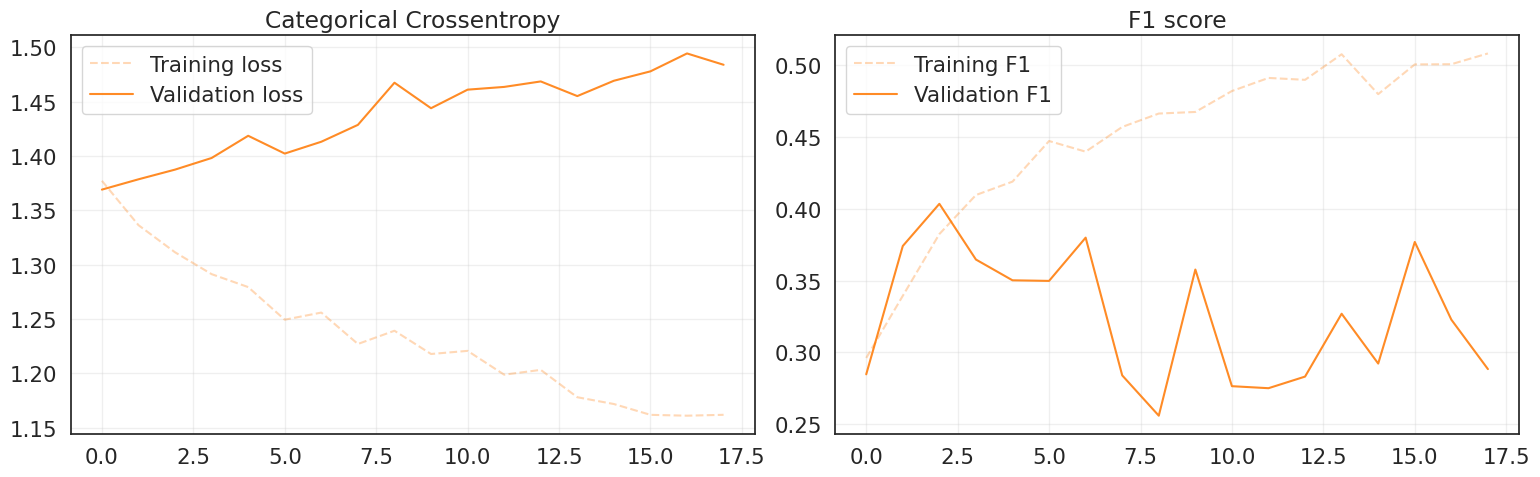

In [102]:
# Create a figure with two side-by-side subplots
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

# Plot of training and validation loss on the first axis
ax1.plot(mil_hist['train_loss'], label='Training loss', alpha=0.3, color='#ff7f0e', linestyle='--')
ax1.plot(mil_hist['val_loss'], label='Validation loss', alpha=0.9, color='#ff7f0e')
ax1.set_title('Categorical Crossentropy')
ax1.legend()
ax1.grid(alpha=0.3)

# Plot of training and validation Accuracy on the second axis
ax2.plot(mil_hist['train_f1'], label='Training F1', alpha=0.3, color='#ff7f0e', linestyle='--')
ax2.plot(mil_hist['val_f1'], label='Validation F1', alpha=0.9, color='#ff7f0e')
ax2.set_title('F1 score')
ax2.legend()
ax2.grid(alpha=0.3)

# Adjust the layout and display the plot
plt.tight_layout()
plt.subplots_adjust(right=0.85)
plt.show()

In [103]:
# --- Fine-Tuning ---

# freeze all parameters
for p in mil_model.parameters():
    p.requires_grad = True

# optimizer with per-group learning rates
optimizer = torch.optim.AdamW(
    [
        {"params": mil_model.classifier.parameters(),     "lr": 1e-4, "weight_decay": 1e-4},
        {"params": mil_model.features.parameters(), "lr": 1e-5, "weight_decay": 1e-4},
    ],
    betas=(0.9, 0.999),
    eps=1e-8,
)

In [104]:
def train_one_epoch_mil(model, loader, criterion, optimizer, scaler, device,
                        pool_method="mean", f1_average="macro"):
    model.train()
    
    running_loss = 0.0
    preds, targs = [], []

    for xb, y in loader:
        xb = xb.to(device, non_blocking=True)
        y  = y.to(device, non_blocking=True)

        B, K, Cc, H, W = xb.shape
        x = xb.view(B*K, Cc, H, W)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type=device.type, enabled=(device.type == "cuda")):
            logits = model(x)                          # [B*K, C]
            logits = logits.view(B, K, -1)             # [B,K,C]
            logits_img = mil_pool(logits, method=pool_method)  # [B,C]
            loss = criterion(logits_img, y)

        if scaler is not None and device.type == "cuda":
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        running_loss += loss.item() * B

        preds.append(logits_img.argmax(dim=1).detach().cpu().numpy())
        targs.append(y.detach().cpu().numpy())

    y_true = np.concatenate(targs)
    y_pred = np.concatenate(preds)

    epoch_loss = running_loss / len(loader.dataset)
    epoch_f1 = f1_score(y_true, y_pred, average=f1_average, zero_division=0)

    return epoch_loss, epoch_f1

In [105]:
%%time
# Fine-tune the model
ft_model, ft_history = fit_mil(
    model=mil_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=120,
    criterion=criterion,
    optimizer=optimizer,
    scaler=scaler,
    device=device,
    patience=20,
    pool_method="mean",
    experiment_name="mil_resnet18_ft"
)

final_val_acc = round(max(ft_history['val_f1']) * 100, 2)
print(f"Best validation F1 ({'weighted'}): {best_val_f1:.4f}")

Epoch   1/120 | Train: 1.2899 F1=0.4370 | Val: 1.3877 F1=0.4040
Epoch   2/120 | Train: 1.2761 F1=0.4712 | Val: 1.3850 F1=0.4452
Epoch   3/120 | Train: 1.2684 F1=0.4589 | Val: 1.3818 F1=0.4071
Epoch   4/120 | Train: 1.2698 F1=0.4230 | Val: 1.3903 F1=0.4085
Epoch   5/120 | Train: 1.2535 F1=0.4443 | Val: 1.3911 F1=0.4018
Epoch   6/120 | Train: 1.2433 F1=0.4831 | Val: 1.3847 F1=0.4359
Epoch   7/120 | Train: 1.2522 F1=0.4469 | Val: 1.4009 F1=0.4250
Epoch   8/120 | Train: 1.2422 F1=0.4237 | Val: 1.4042 F1=0.3901
Epoch   9/120 | Train: 1.2202 F1=0.4776 | Val: 1.4084 F1=0.3869
Epoch  10/120 | Train: 1.2237 F1=0.4812 | Val: 1.4017 F1=0.3929
Epoch  11/120 | Train: 1.2094 F1=0.4464 | Val: 1.4107 F1=0.4005
Epoch  12/120 | Train: 1.1903 F1=0.4955 | Val: 1.4236 F1=0.3403
Epoch  13/120 | Train: 1.2195 F1=0.4527 | Val: 1.4127 F1=0.4085
Epoch  14/120 | Train: 1.1979 F1=0.4892 | Val: 1.4458 F1=0.3878
Epoch  15/120 | Train: 1.1873 F1=0.4685 | Val: 1.4227 F1=0.3716
Epoch  16/120 | Train: 1.1496 F1=0.5196 

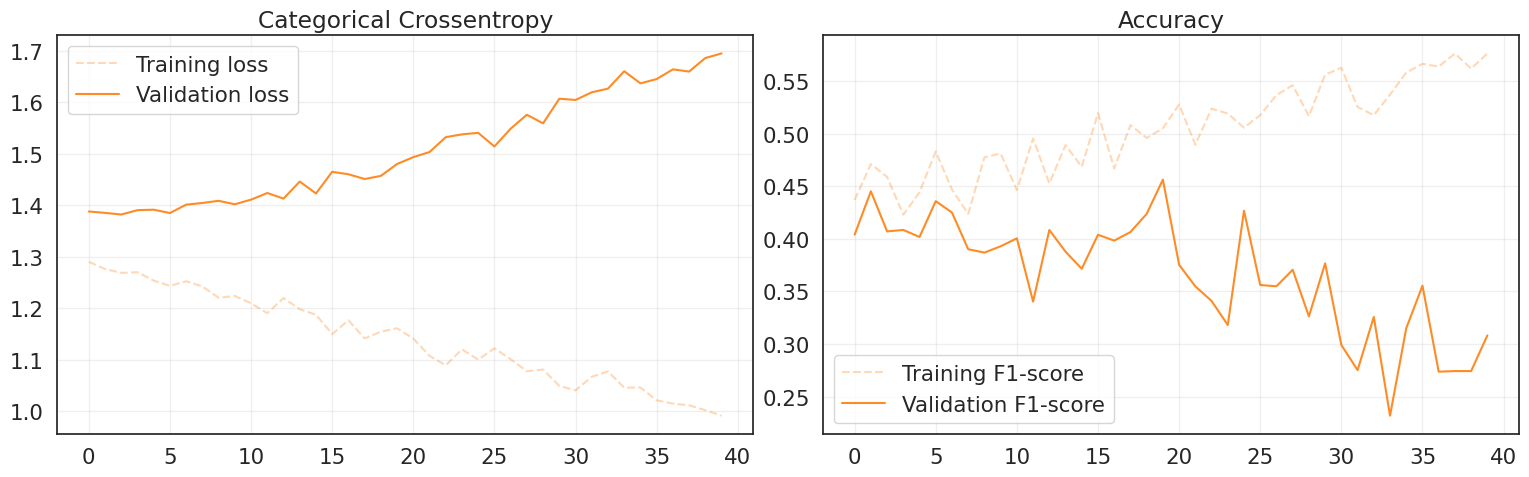

In [106]:
# Create a figure with two side-by-side subplots
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

# Plot of training and validation loss on the first axis
ax1.plot(ft_history['train_loss'], label='Training loss', alpha=0.3, color='#ff7f0e', linestyle='--')
ax1.plot(ft_history['val_loss'], label='Validation loss', alpha=0.9, color='#ff7f0e')
ax1.set_title('Categorical Crossentropy')
ax1.legend()
ax1.grid(alpha=0.3)

# Plot of training and validation Accuracy on the second axis
ax2.plot(ft_history['train_f1'], label='Training F1-score', alpha=0.3, color='#ff7f0e', linestyle='--')
ax2.plot(ft_history['val_f1'], label='Validation F1-score', alpha=0.9, color='#ff7f0e')
ax2.set_title('Accuracy')
ax2.legend()
ax2.grid(alpha=0.3)

# Adjust the layout and display the plot
plt.tight_layout()
plt.subplots_adjust(right=0.85)
plt.show()

## Evaluation

In [107]:
# Load the fine-tuned model for inference
best_model = ft_model

print("Model loaded successfully!")

Model loaded successfully!


In [108]:
test_data, test_masks, test_file_names = load_images_from_folder("/kaggle/input/an2dl2526c2v2/test_data")
print(f"Loaded {len(test_data)} data")

Loaded 477 data


In [109]:
int_to_label = {
    0 : "Triple negative",
    1 : "Luminal A",
    2 : "Luminal B",
    3 : "HER2(+)"
}

def predict_one_image_mil(best_model, img, mask, patch=380, k=16, pool_method="mean"):
    best_model.eval()
    patches = extract_patches_maskaware(img, mask, patch=patch, n_patches=k)

    xb = []
    for ip, mp in patches:
        # DO NOT zero background unless you have evidence it helps.
        xb.append(val_transforms(ip))
    xb = torch.stack(xb).to(device)  # [K,3,H,W]

    with torch.no_grad(), torch.amp.autocast(device_type=device.type, enabled=(device.type=='cuda')):
        logits = model(xb)               # [K,C]
        logits = logits.unsqueeze(0)     # [1,K,C]
        pooled = mil_pool(logits, method=pool_method).squeeze(0)  # [C]
        pred = pooled.argmax().item()
    return pred

# build submission

sample_indices, predictions = [], []
for img, mask, fname in zip(test_data, test_masks, test_file_names):
    p = predict_one_image_mil(best_model, img, mask, patch=380, k=4, pool_method="mean")
    sample_indices.append(fname)
    predictions.append(int_to_label[int(p)])

submission_df = pd.DataFrame({
    'sample_index': sample_indices,
    'label': predictions
}).sort_values("sample_index").reset_index(drop=True)

os.makedirs("/kaggle/working/submissions", exist_ok=True)
submission_df.to_csv('/kaggle/working/submissions/mil_ENB4Patch380.csv', index=False)